## How YOLO works
The algorithm works based on the following four approaches: 
- Residual blocks
- Bounding box regression
    - Y = [pc, bx, by, bh, bw, c1, c2]
        - pc corresponds to the probability score of the grid containing an object. For instance, all the grids in red will have a probability score higher than zero. The image on the right is the simplified version since the probability of each yellow cell is zero (insignificant). 
        - bx, by are the x and y coordinates of the center of the bounding box with respect to the enveloping grid cell. 
        - bh, bw correspond to the height and the width of the bounding box with respect to the enveloping grid cell. 
        - c1 and c2 correspond to the two classes, Player and Ball. We can have as many classes as your use case requires. 
- Intersection Over Unions or IOU for short
- Non-Maximum Suppression. 

In [1]:
!nvidia-smi

Fri May 16 19:57:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.52.04              Driver Version: 555.52.04      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     Off |   00000000:22:00.0 Off |                  N/A |
| 30%   25C    P8              9W /  250W |   10819MiB /  11264MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from ultralytics import YOLO
import torch
import os

In [4]:
# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU Available: True
GPU Name: NVIDIA GeForce RTX 2080 Ti


In [5]:
model_11 = YOLO("yolo11n.pt")

##TRAIN
model_11.train( 
    data='nvd.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo_nvd_snow',
    workers=4,
)

##EVALUATE
metrics = model_11.val()
metrics

Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=nvd.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_nvd_snow6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

train: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/train.cache... 4355 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4355/4355 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 288.0±76.5 MB/s, size: 3555.1 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]


Plotting labels to runs/detect/yolo_nvd_snow6/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to runs/detect/yolo_nvd_snow6
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 91/91 [00:17<00:00,  5.22it/s]


                   all       2904       9175      0.964      0.949      0.983      0.783
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/yolo_nvd_snow6
Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4309.5±598.4 MB/s, size: 3383.4 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:36<00:00,  5.06it/s]


                   all       2904       9175      0.964       0.95      0.984       0.79
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/detect/yolo_nvd_snow62


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fbe38de6f10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [6]:
model_10 = YOLO("yolov10n.pt")

##TRAIN
model_10.train( 
    data='nvd.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo_nvd_snow',
    workers=4,
)

##EVALUATE
metrics = model_10.val()
metrics

100%|██████████| 5.59M/5.59M [00:00<00:00, 51.4MB/s]


Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=nvd.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_nvd_snow7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pr

train: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/train.cache... 4355 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4355/4355 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2809.0±1518.1 MB/s, size: 3555.1 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 91/91 [00:16<00:00,  5.38it/s]


                   all       2904       9175      0.955      0.933      0.979      0.793
Speed: 0.1ms preprocess, 0.7ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to runs/detect/yolo_nvd_snow7
Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
YOLOv10n summary (fused): 102 layers, 2,265,363 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4269.2±1537.1 MB/s, size: 3383.4 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:35<00:00,  5.07it/s]


                   all       2904       9175      0.955      0.934      0.979      0.794
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to runs/detect/yolo_nvd_snow72


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fbe2a78bb90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [9]:
model_9 = YOLO("yolov9c.pt")

##TRAIN
model_9.train( 
    data='nvd.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolo_nvd_snow',
    workers=4,
)

##EVALUATE
metrics = model_9.val()
metrics

100%|██████████| 49.4M/49.4M [00:00<00:00, 80.3MB/s]


Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=nvd.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_nvd_snow8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pre

train: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/train.cache... 4355 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4355/4355 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2710.3±1555.6 MB/s, size: 3555.1 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 91/91 [00:21<00:00,  4.25it/s]


                   all       2904       9175      0.981      0.966      0.991      0.821
Speed: 0.1ms preprocess, 3.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/yolo_nvd_snow8
Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4070.0±618.5 MB/s, size: 3383.4 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:36<00:00,  4.98it/s]


                   all       2904       9175      0.981      0.965      0.991      0.829
Speed: 0.2ms preprocess, 6.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/yolo_nvd_snow82


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fbe09a2b950>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [34]:
results = model.predict(source="/car-detection-in-snow/datasets/inference-pictures", save=True, conf=0.25)


image 1/2 /car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-04-23 144515.png: 288x640 (no detections), 13.6ms
image 2/2 /car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-04-23 144647.png: 320x640 1 car, 47.1ms
Speed: 2.0ms preprocess, 30.4ms inference, 0.9ms postprocess per image at shape (1, 3, 320, 640)
Results saved to runs/detect/yolo_nvd_snow4


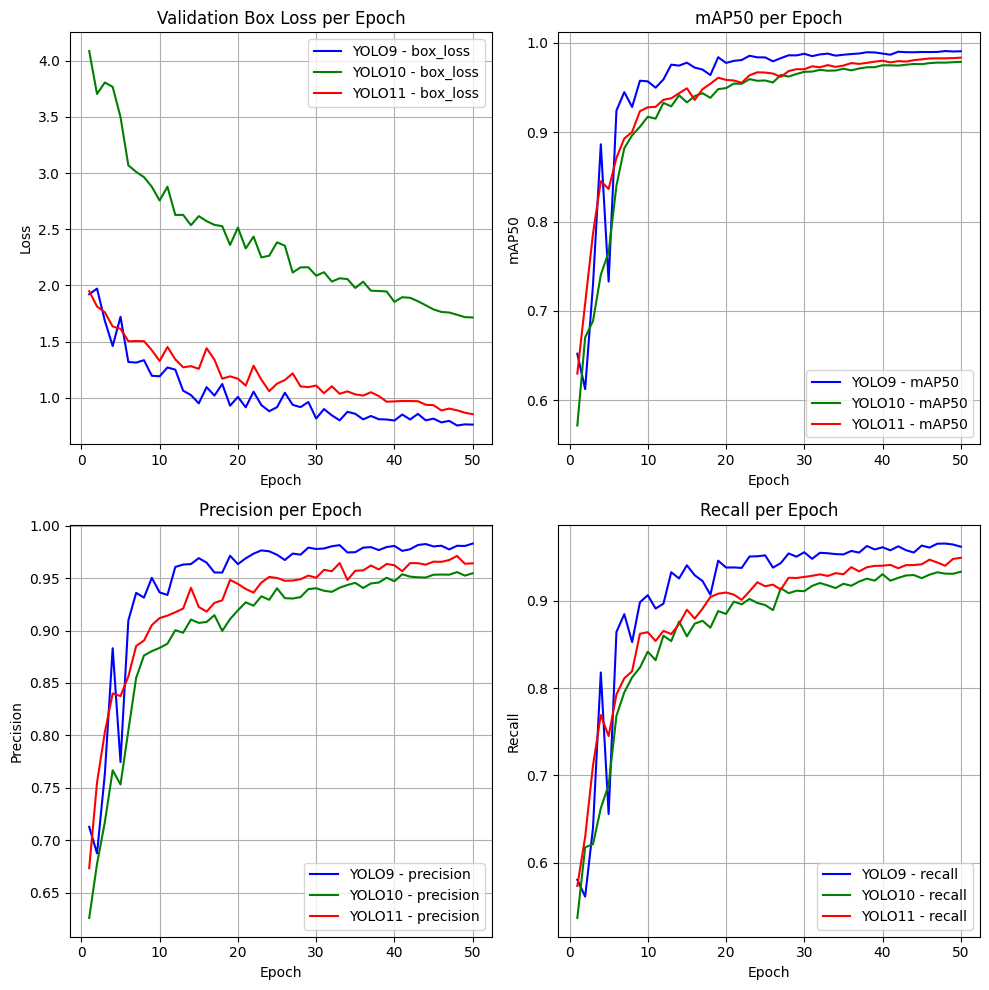

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Define paths
paths = {
    "YOLO9": "runs/detect/yolo9_nvd_snow8/results.csv",
    "YOLO10": "runs/detect/yolo10_nvd_snow7/results.csv",
    "YOLO11": "runs/detect/yolo11_nvd_snow6//results.csv"
}

# Colors for plots
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 10))

# --- Plot box loss ---
plt.subplot(2, 2, 1)
for i, (label, path) in enumerate(paths.items()):
    df = pd.read_csv(path)
    plt.plot(df['epoch'], df['val/box_loss'], label=f'{label} - box_loss', color=colors[i])
plt.title('Validation Box Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# --- Plot mAP50 ---
plt.subplot(2, 2, 2)
for i, (label, path) in enumerate(paths.items()):
    df = pd.read_csv(path)
    plt.plot(df['epoch'], df['metrics/mAP50(B)'], label=f'{label} - mAP50', color=colors[i])
plt.title('mAP50 per Epoch')
plt.xlabel('Epoch')
plt.ylabel('mAP50')
plt.legend()
plt.grid()

# --- Plot precision ---
plt.subplot(2, 2, 3)
for i, (label, path) in enumerate(paths.items()):
    df = pd.read_csv(path)
    plt.plot(df['epoch'], df['metrics/precision(B)'], label=f'{label} - precision', color=colors[i])
plt.title('Precision per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid()

# --- Plot recall ---
plt.subplot(2, 2, 4)
for i, (label, path) in enumerate(paths.items()):
    df = pd.read_csv(path)
    plt.plot(df['epoch'], df['metrics/recall(B)'], label=f'{label} - recall', color=colors[i])
plt.title('Recall per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid()

# save figure
plt.savefig("comparison.png", dpi=600)

plt.tight_layout()
plt.show()





In [3]:
best_model_9 = YOLO("runs/detect/yolo9_nvd_snow8/weights/best.pt")
best_model_10 = YOLO("runs/detect/yolo10_nvd_snow7/weights/best.pt")
best_model_11 = YOLO("runs/detect/yolo11_nvd_snow6/weights/best.pt")

In [8]:
##Test Performance##
test_results_11 = best_model_11.val(data="nvd.yaml")
test_results_10 = best_model_10.val(data="nvd.yaml")
test_results_9 = best_model_9.val(data="nvd.yaml")
print(test_results_11)
print(test_results_10)
print(test_results_9)

Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 276.8±39.0 MB/s, size: 3048.8 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:23<00:00,  7.61it/s]


                   all       2904       9175      0.964       0.95      0.984       0.79
Speed: 0.1ms preprocess, 1.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs/detect/val
Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2432.6±849.9 MB/s, size: 3061.6 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:18<00:00,  9.68it/s]


                   all       2904       9175      0.955      0.934      0.979      0.794
Speed: 0.1ms preprocess, 1.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to runs/detect/val2
Ultralytics 8.3.137 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 11005MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2757.9±1371.7 MB/s, size: 3536.4 KB)


val: Scanning /car-detection-in-snow/datasets/Labeled Frames (YOLO Format)/labels/val.cache... 2904 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2904/2904 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:30<00:00,  6.00it/s]


                   all       2904       9175      0.981      0.965      0.991      0.829
Speed: 0.1ms preprocess, 6.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fbd70388ad0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.03303

In [10]:
##Inference##
results9 = best_model_9.predict(source="/car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-05-17 161229.png", save=True, conf=0.293)
results10 = best_model_10.predict(source="/car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-05-17 161229.png", save=True, conf=0.293)
results11 = best_model_11.predict(source="/car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-05-17 161229.png", save=True, conf=0.293)


image 1/1 /car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-05-17 161229.png: 352x640 (no detections), 17.8ms
Speed: 20.2ms preprocess, 17.8ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 640)
Results saved to runs/detect/predict

image 1/1 /car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-05-17 161229.png: 352x640 (no detections), 23.1ms
Speed: 2.1ms preprocess, 23.1ms inference, 4.1ms postprocess per image at shape (1, 3, 352, 640)
Results saved to runs/detect/predict3

image 1/1 /car-detection-in-snow/datasets/inference-pictures/Screenshot 2025-05-17 161229.png: 352x640 1 car, 10.2ms
Speed: 2.3ms preprocess, 10.2ms inference, 1.6ms postprocess per image at shape (1, 3, 352, 640)
Results saved to runs/detect/predict2
